This notebook accompagnies the lecture on 

***Reasoning and decision-making models***

It demonstrates Bayesian updating of defect distribution and failure proability after an inspection 
& it determines the value of information of the test

- A structural component may contain a defect. Its size $D$ is **lognormally distributed** with mean $1$ and standard deviation $1$.
- The component **fails if $D > 5$**.
- An inspection can be carried out. It has a **probability of detection**
$$
POD(d) = 1-\exp(-d),
$$
i.e. the larger the true defect, the more likely it is to be found.


What is the probability of failure *a priori* (before any inspection), and what is it *after* an inspection is carried out and *finds no defect*?

In [37]:
import numpy as np
from scipy.stats import lognorm, norm
from scipy.integrate import quad, trapezoid
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(42)   # reproducible random numbers

d_fail = 5.0   # failure threshold: component fails if D > d_fail


***Prior distribution of the defect size $D$***

$D$ is lognormal with **mean** $m = 1$ and **standard deviation** $s = 1$ (in the *real*, not log, space).

If $\ln D \sim \mathcal{N}(\mu, \sigma^2)$, then the mean and standard deviation of $D$ itself are related to $\mu,\sigma$ by

$$
\sigma^2 = \ln\!\left(1 + \frac{s^2}{m^2}\right), \qquad
\mu = \ln(m) - \frac{\sigma^2}{2}
$$


In [38]:
mean_D, std_D = 1.0, 1.0

sigma = np.sqrt(np.log(1 + (std_D / mean_D) ** 2))
mu = np.log(mean_D) - sigma ** 2 / 2

prior = lognorm(s=sigma, scale=np.exp(mu))

print(f"mu    = {mu:.4f}")
print(f"sigma = {sigma:.4f}")

# sanity check: does the distribution really have the mean & std we started from?
print(f"check: mean(D) = {prior.mean():.4f}, std(D) = {prior.std():.4f}")


mu    = -0.3466
sigma = 0.8326
check: mean(D) = 1.0000, std(D) = 1.0000


***Prior probability of failure***

The component fails if $D > 5$, so
$$
P_f^{\text{prior}} = P(D>5) = \int_{5}^{\infty} f_D(d)\,\mathrm{d}d = 1-F_D(5).
$$


In [39]:
Pf_prior= prior.sf(d_fail)                 # 1 - CDF(5)
print(f"P(D>5) = {Pf_prior:.6e}")

P(D>5) = 9.401614e-03


***The inspection: detection probability and likelihood***

$$
POD(d) = 1-\exp(-d)
$$

If the inspection finds **no defect**, that outcome has likelihood
$$
L(d) = P(\text{no detection}\mid D=d) = 1-POD(d) = e^{-d}.
$$


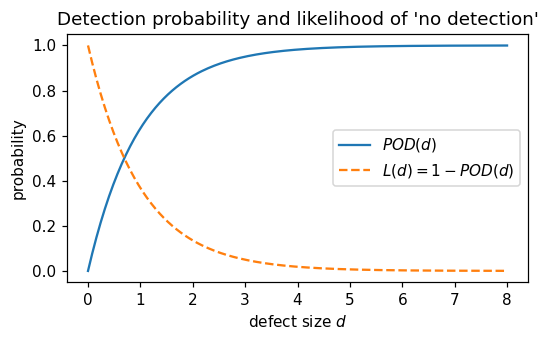

In [40]:
# POD(d): probability that an inspection detects a defect of true size d.
def POD(d):
    return 1 - np.exp(-d)

# L(d): likelihood of a 'no detection' outcome, given a true defect size d.
def L(d):
    return 1 - POD(d)   # = exp(-d)

d_plot = np.linspace(0, 8, 200)
plt.figure(figsize=(5, 3.2))
plt.plot(d_plot, POD(d_plot), label="$POD(d)$")
plt.plot(d_plot, L(d_plot), label="$L(d)=1-POD(d)$", linestyle="--")
plt.xlabel("defect size $d$")
plt.ylabel("probability")
plt.title("Detection probability and likelihood of 'no detection'")
plt.legend()
plt.tight_layout()
plt.show()


***Bayesian updating via numerical integration***

By Bayes' theorem, the posterior density of $D$ given "no detection" is
$$
f_D(d\mid E) = \frac{L(d)\,f_D(d)}{C}, \qquad C = \int_0^\infty L(d')\,f_D(d')\,\mathrm{d}d'.
$$

$C$ is the **evidence**: the prior (marginal) probability of observing "no detection" at all. We compute it — and the posterior — numerically:

1. Build a fine grid of $d$ values.
2. Evaluate the prior pdf $f_D(d)$ and the likelihood $L(d)$ on the grid.
3. Numerically integrate (`trapezoid`) ` f_prior * L` over the grid to get the normalizing constant $C$.
4. Posterior pdf = `f_prior * L / C`.
6. Posterior probability of failure = numerically integrate the posterior pdf over $d>5$.


In [ ]:
# Compute the posterior probability of failure given no detection

d_grid = np.linspace(1e-8, 60, 400_000)   # fine grid; pdf is ~0 well before d=60

f_prior = prior.pdf(d_grid)
Lvals = L(d_grid)

weighted = f_prior * Lvals              # prior "weighted" by the likelihood
P_Nodetect = trapezoid(weighted, d_grid)  # normalizing constant = P(no detection)
f_posterior =                                  # <-- Fill out here for posterior pdf

# sanity check: posterior pdf should integrate to 1
print("check, integral of posterior pdf:", trapezoid(f_posterior, d_grid))

mask = d_grid > d_fail
Pf_posterior_nodetect = trapezoid(f_posterior[mask], d_grid[mask])

print(f"Evidence C = P(no detection)      = {P_Nodetect:.4f}")
print(f"Posterior P(D>5 | no detection)  = {Pf_posterior_nodetect:.4e}")
print(f"Reduction factor Pf_prior/Pf_post = {Pf_prior / Pf_posterior_nodetect:,.0f}x")

# Compute the posterior probability of failure given defect detection
Lvals_detect = 1-L(d_grid)

weighted_detect = f_prior * Lvals_detect           # prior "weighted" by the likelihood
P_detect = trapezoid(weighted_detect, d_grid)         # normalizing constant = P(no detection)
f_posterior_detect =                                 # <-- Fill out here for posterior pdf

# check: posterior pdf should integrate to 1
print("check, integral of posterior pdf:", trapezoid(f_posterior_detect, d_grid))

Pf_posterior_detect = trapezoid(f_posterior_detect[mask], d_grid[mask])

print(f"Posterior P(D>5 | detection)  = {Pf_posterior_detect:.4e}")


check, integral of posterior pdf: 1.0
Evidence C = P(no detection)      = 0.4751
Posterior P(D>5 | no detection)  = 5.0155e-05
Reduction factor Pf_prior/Pf_post = 187x
check, integral of posterior pdf: 1.0000000000000002
Posterior P(D>5 | detection)  = 1.7863e-02


***Results summary***

In [42]:
print("="*58)
print(f"{'Prior probability of failure P(D>5)':<42}{Pf_prior:>14.4e}")
print(f"{'Posterior prob. of failure, given no detection':<42}{Pf_posterior_nodetect:>14.4e}")
print(f"{'Posterior prob. of failure, given detection':<42}{Pf_posterior_detect:>14.4e}")
print("="*58)


Prior probability of failure P(D>5)           9.4016e-03
Posterior prob. of failure, given no detection    5.0155e-05
Posterior prob. of failure, given detection    1.7863e-02


***Plot: prior, likelihood, and posterior for no-detection***

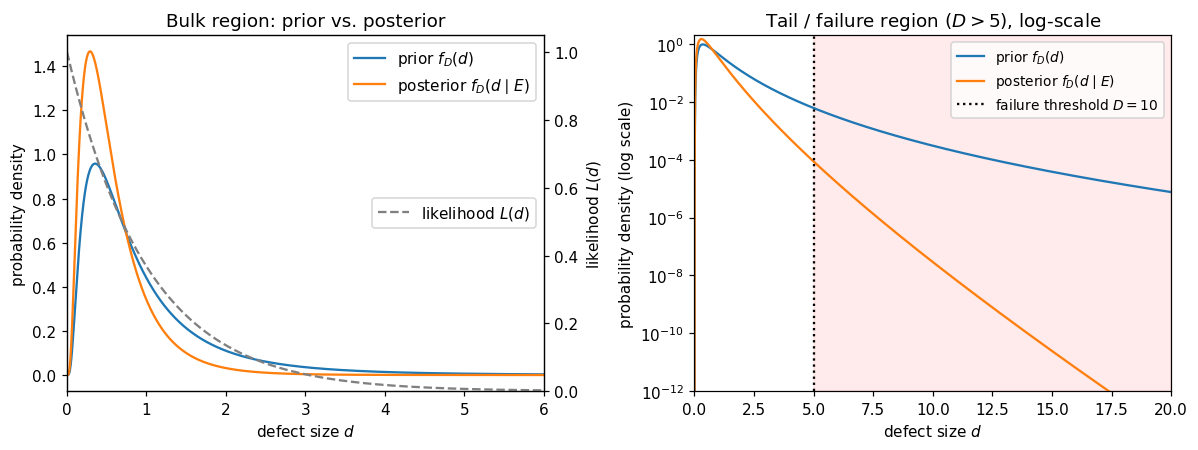

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# --- Left panel: bulk of the distribution -----------------------------
ax = axes[0]
d_bulk = np.linspace(1e-6, 6, 2000)
ax.plot(d_bulk, prior.pdf(d_bulk), color="C0", label="prior $f_D(d)$")
ax.plot(d_grid, f_posterior, color="C1", label="posterior $f_D(d\\mid E)$")
ax.set_xlim(0, 6)
ax.set_xlabel("defect size $d$")
ax.set_ylabel("probability density")
ax.legend(loc="upper right")

ax2 = ax.twinx()
ax2.plot(d_bulk, L(d_bulk), color="grey", linestyle="--", label="likelihood $L(d)$")
ax2.set_ylabel("likelihood $L(d)$")
ax2.set_ylim(0, 1.05)
ax2.legend(loc="center right")
ax.set_title("Bulk region: prior vs. posterior")

# --- Right panel: tail / failure region --------------------------------
ax = axes[1]
d_tail = np.linspace(1e-6, 20, 4000)
ax.plot(d_tail, prior.pdf(d_tail), color="C0", label="prior $f_D(d)$")
ax.plot(d_grid, f_posterior, color="C1", label="posterior $f_D(d\\mid E)$")
ax.axvline(d_fail, color="k", linestyle=":", label="failure threshold $D=10$")
ax.axvspan(d_fail, 20, color="red", alpha=0.08)
ax.set_yscale("log")
ax.set_xlim(0, 20)
ax.set_ylim(1e-12, 2)
ax.set_xlabel("defect size $d$")
ax.set_ylabel("probability density (log scale)")
ax.legend(loc="upper right", fontsize=9)
ax.set_title("Tail / failure region ($D>5$), log-scale")

plt.tight_layout()
plt.show()


*** Part 2: Determine the value of information of the inspection ***


In [44]:
# Analysing the a-priori optimal decision and expected utility/cost

c_R = 1e3    # replacement cost [EUR]
c_F = 1e5    # failure cost [EUR]

cost_a0_prior = Pf_prior * c_F   # expected cost of "do nothing"
cost_a1_prior = c_R                      # expected cost of "replace"

a0_cost = min(cost_a0_prior, cost_a1_prior)   # optimal expected cost, no inspection
best_action_prior = "do nothing" if cost_a0_prior <= cost_a1_prior else "replace"

print(f"E[cost | do nothing] = {cost_a0_prior:10.3f} EUR")
print(f"E[cost | replace]    = {cost_a1_prior:10.3f} EUR")
print(f"--> optimal action WITHOUT inspection: {best_action_prior!r}, expected cost = {a0_cost:.3f} EUR")


E[cost | do nothing] =    940.161 EUR
E[cost | replace]    =   1000.000 EUR
--> optimal action WITHOUT inspection: 'do nothing', expected cost = 940.161 EUR


In [ ]:
Ecost_no_detect = min(c_R, Pf_posterior_nodetect * c_F)
Ecost_detect = min(c_R, Pf_posterior_detect * c_F)
best_no_detect = "do nothing" if Ecost_no_detect == Pf_posterior_nodetect*c_F else "replace"
best_detect = "do nothing" if Ecost_detect == Pf_posterior_detect*c_F else "replace"

Ecost_inspect =                                 # <-- Fill out here 
VoI =                                           # <-- Fill out here 

print()
print(f"If NO detection (P={P_Nodetect:.4f}): optimal action = {best_no_detect!r}, cost = {cost_no_detect:.4f} EUR")
print(f"If detection    (P={P_detect:.4f}): optimal action = {best_detect!r}, cost = {cost_detect:.4f} EUR")
print()
print(f"E[cost | inspect] = {EC_inspect:.4f} EUR   (vs. E[cost | no info] = {a0_cost:.4f} EUR)")
print(f"Value of Information (this inspection) = {VoI:.4f} EUR  (should be >= 0)")



If NO detection (P=0.4751): optimal action = 'do nothing', cost = 5.0155 EUR
If detection    (P=0.5249): optimal action = 'replace', cost = 1000.0000 EUR

E[cost | inspect] = 527.3248 EUR   (vs. E[cost | no info] = 940.1614 EUR)
Value of Information (this inspection) = 412.8365 EUR  (should be >= 0)
